In [1]:
## Setup — packages & environment

import sys
import subprocess

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

required = [
    'pandas', 'numpy', 'scipy', 'matplotlib', 'seaborn', 'scikit-learn',
    'editdistance', 'openpyxl', 'reportlab'
]

for pkg in required:
    try:
        __import__(pkg.split('-')[0])
    except Exception:
        install(pkg)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime as dt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import editdistance

RSEED = 2023
np.random.seed(RSEED)

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

In [2]:
try:
    import ipykernel
    print('ipykernel is installed:', ipykernel.__version__)
except Exception as e:
    print('ipykernel is NOT installed.')

ipykernel is installed: 6.28.0


In [3]:
## 1. Data Loading and Sequence Preparation

DATA_DIR = '../../data-main/1_moodleLAcourse'

# Create synthetic event sequences for demonstration
np.random.seed(RSEED)
event_types = ['forum', 'quiz', 'assignment', 'video', 'wiki']
n_students = 25

sequences = []
for i in range(n_students):
    seq_length = np.random.randint(8, 20)
    seq = ''.join([event_types[j][0] for j in np.random.choice(len(event_types), seq_length)])
    sequences.append(seq)

data = pd.DataFrame({
    'student_id': [f'student_{i}' for i in range(n_students)],
    'sequence': sequences
})

print('Event Sequence Data:')
print(data.head(10))
print(f'\nTotal students: {len(data)}')
print(f'Event types: {event_types}')

Event Sequence Data:
  student_id             sequence
0  student_0      qqwvwwfqfavawqf
1  student_1      qfavfqfqavqfqwf
2  student_2     wqwqaqfvwvvawfwa
3  student_3  qwvvfvqavqvwvqwfaaq
4  student_4           afwwawfwqv
5  student_5         fwawffafqfqw
6  student_6  aaffvawvwwwqwvqavqa
7  student_7    aaawfvavvvwfwqwvv
8  student_8  wwvfqvfaqwvvvqwqvwq
9  student_9         faqwvwqvwaaq

Total students: 25
Event types: ['forum', 'quiz', 'assignment', 'video', 'wiki']


In [4]:
## 2. Exploratory Analysis

seq_lengths = data['sequence'].str.len()
print('Sequence Length Statistics:')
print(seq_lengths.describe())

# Event frequency analysis
event_freq = {}
for event_type in event_types:
    event_freq[event_type] = sum(event_type[0] in seq for seq in data['sequence'])

print('\nEvent Type Frequencies Across Sequences:')
for event, count in sorted(event_freq.items(), key=lambda x: x[1], reverse=True):
    print(f'{event}: {count}')

Sequence Length Statistics:
count    25.000000
mean     14.320000
std       3.613862
min       8.000000
25%      11.000000
50%      15.000000
75%      17.000000
max      19.000000
Name: sequence, dtype: float64

Event Type Frequencies Across Sequences:
quiz: 25
forum: 24
assignment: 24
wiki: 24
video: 23


In [5]:
## 3. Sequence Distance Metrics

def levenshtein_distance(s1, s2):
    return editdistance.eval(s1, s2)

def lcs_length(s1, s2):
    """Longest Common Subsequence length"""
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[m][n]

def lcs_distance(s1, s2):
    """Normalized LCS distance"""
    lcs_len = lcs_length(s1, s2)
    max_len = max(len(s1), len(s2))
    return 1 - (lcs_len / max_len) if max_len > 0 else 0

# Compute distance matrices
n_seqs = len(data)
levenshtein_dist = np.zeros((n_seqs, n_seqs))
lcs_dist = np.zeros((n_seqs, n_seqs))

print('Computing sequence distances...')
for i in range(n_seqs):
    for j in range(i+1, n_seqs):
        lev = levenshtein_distance(data['sequence'].iloc[i], data['sequence'].iloc[j])
        lcs = lcs_distance(data['sequence'].iloc[i], data['sequence'].iloc[j])
        levenshtein_dist[i, j] = levenshtein_dist[j, i] = lev
        lcs_dist[i, j] = lcs_dist[j, i] = lcs

print('Distance computation complete.')
print(f'Levenshtein distance: min={levenshtein_dist[levenshtein_dist > 0].min():.1f}, max={levenshtein_dist.max():.1f}')
print(f'LCS distance: min={lcs_dist[lcs_dist > 0].min():.3f}, max={lcs_dist.max():.3f}')

Computing sequence distances...
Distance computation complete.
Levenshtein distance: min=4.0, max=15.0
LCS distance: min=0.312, max=0.923


In [6]:
## 4. Sequence Clustering

# Hierarchical clustering based on Levenshtein distance
condensed_dist = squareform(levenshtein_dist)
Z = linkage(condensed_dist, method='ward')

# Cut dendrogram at optimal height
n_clusters = 3
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust') - 1
data['Cluster'] = cluster_labels

print(f'Cluster distribution (k={n_clusters}):')  
print(data['Cluster'].value_counts().sort_index())

Cluster distribution (k=3):
Cluster
0    12
1     6
2     7
Name: count, dtype: int64


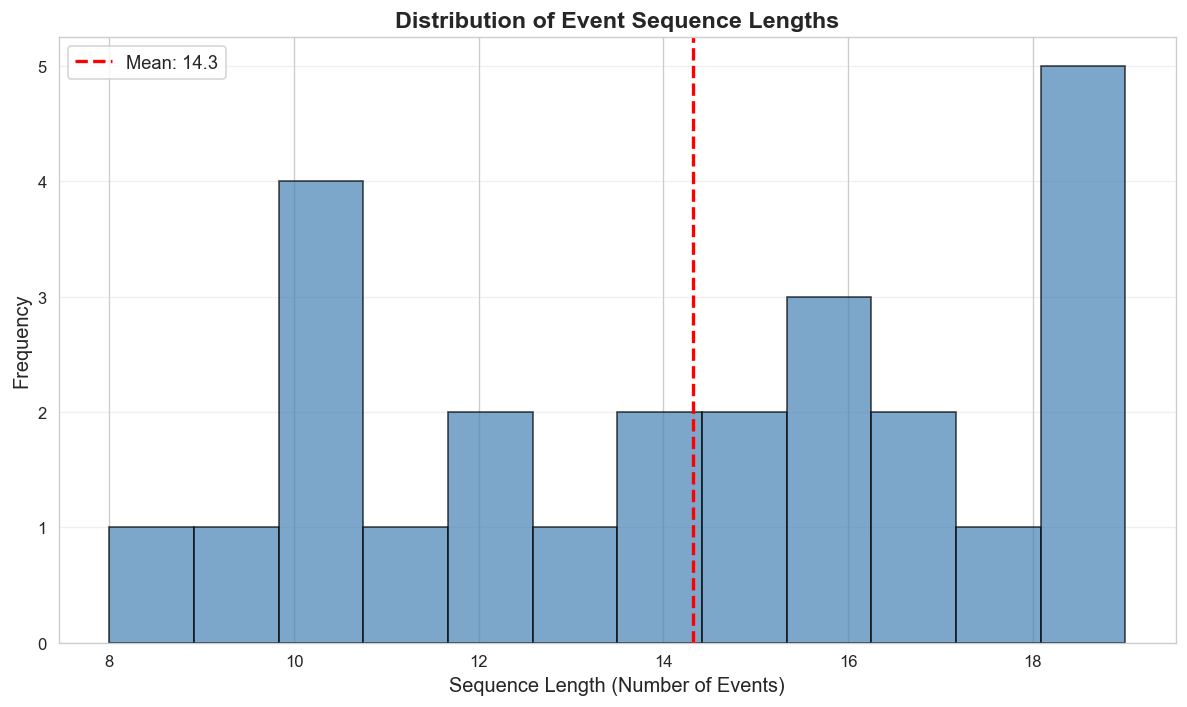

Saved: 01_sequence_length_dist.png


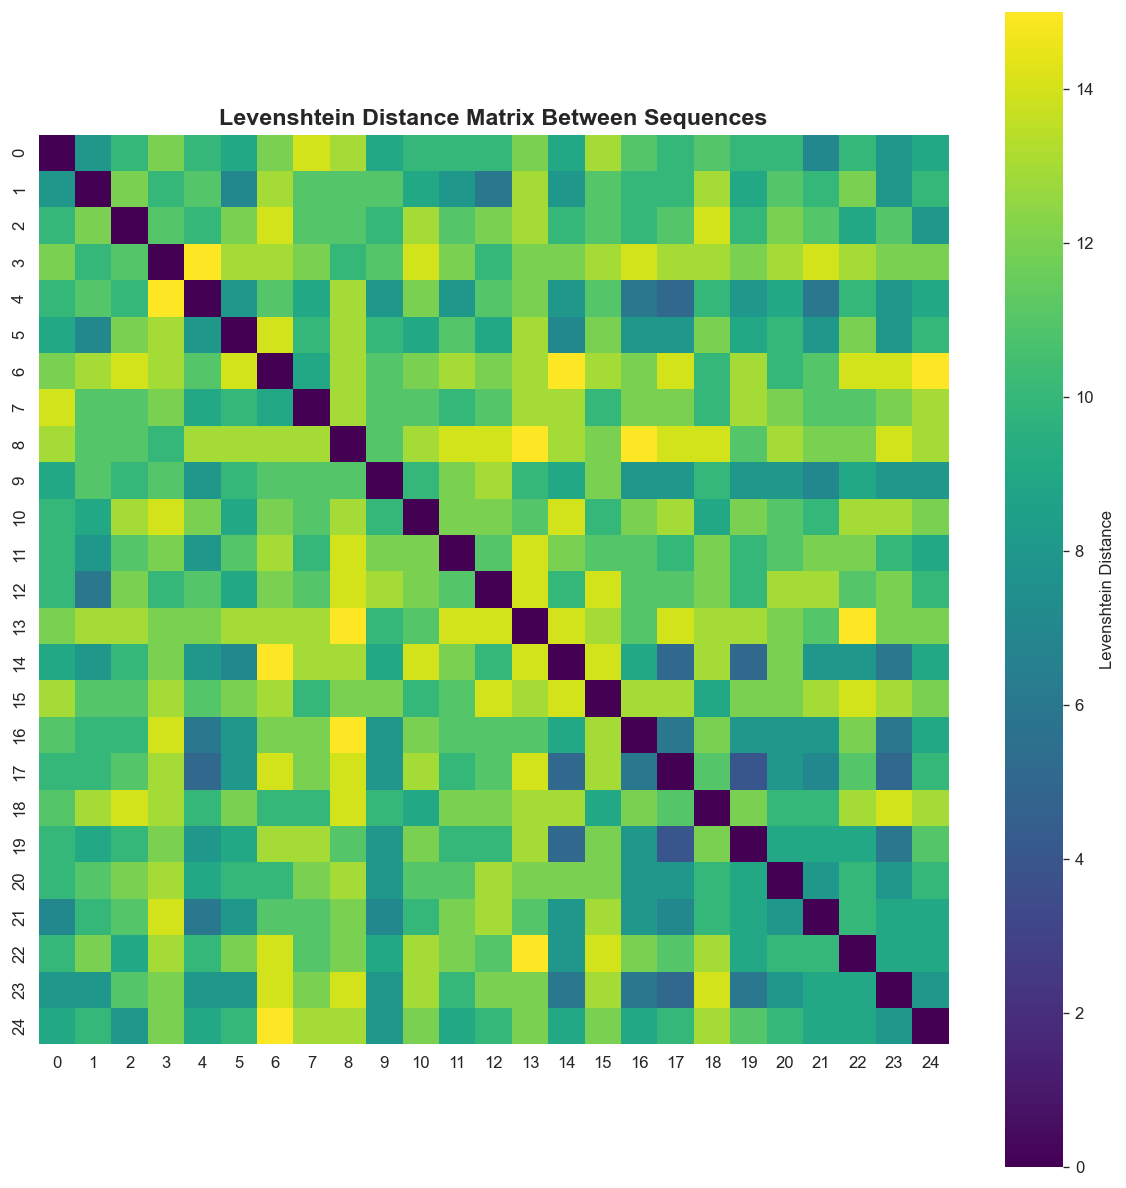

Saved: 02_distance_matrix.png


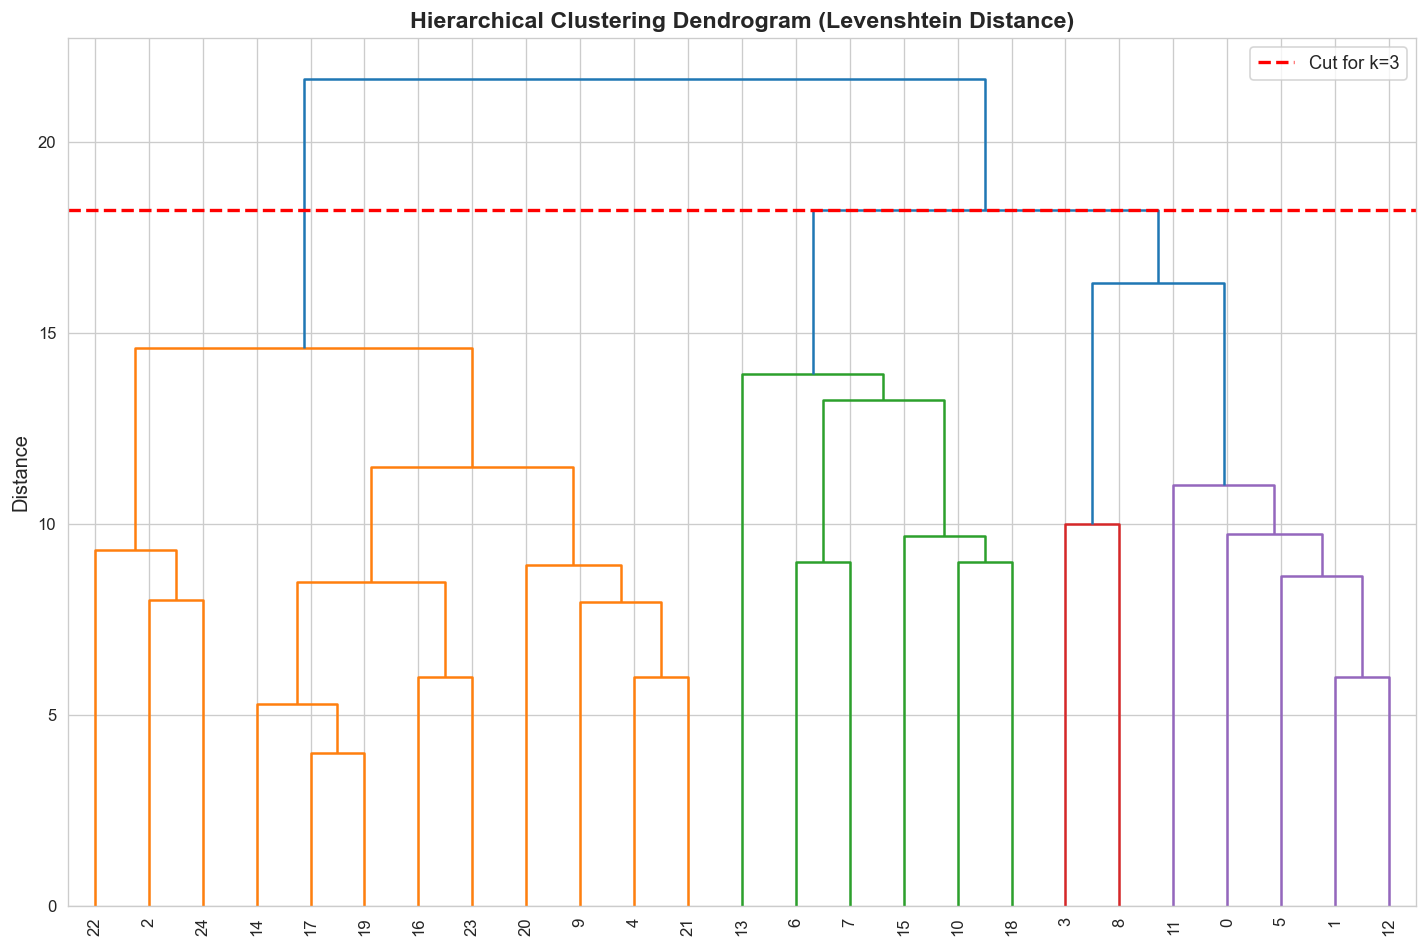

Saved: 03_dendrogram.png


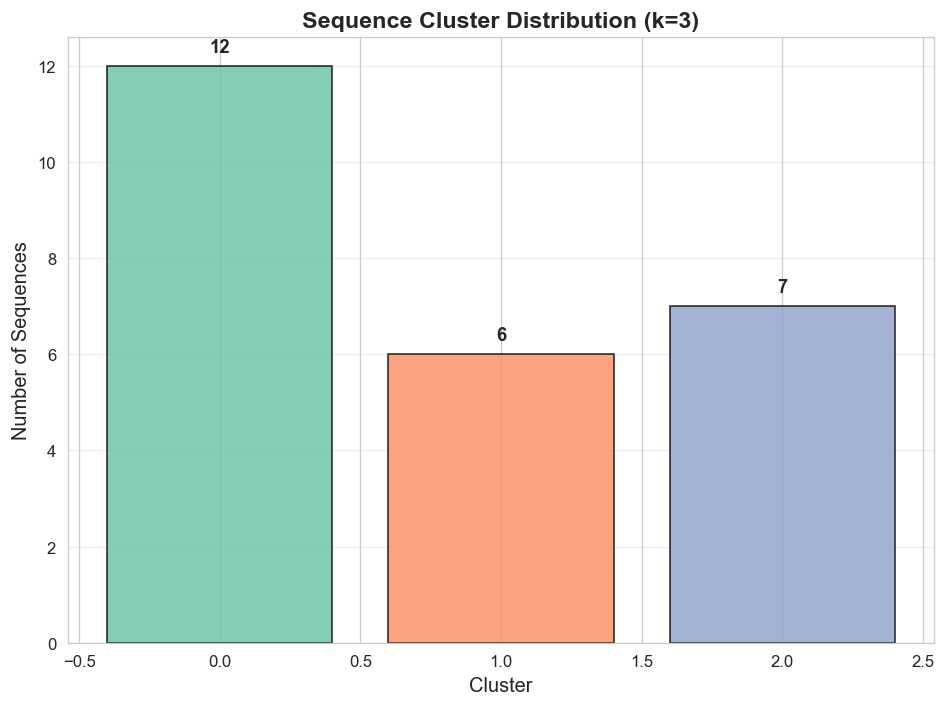

Saved: 04_cluster_sizes.png

Saved sequence clustering results to sequence_clustering_results.csv


In [7]:
## 5. Visualizations

os.makedirs('figures', exist_ok=True)

# 1. Sequence length distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(seq_lengths, bins=12, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(seq_lengths.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {seq_lengths.mean():.1f}')
ax.set_xlabel('Sequence Length (Number of Events)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Event Sequence Lengths', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/01_sequence_length_dist.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 01_sequence_length_dist.png')

# 2. Distance matrix heatmap
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(levenshtein_dist, cmap='viridis', square=True, ax=ax, cbar_kws={'label': 'Levenshtein Distance'})
ax.set_title('Levenshtein Distance Matrix Between Sequences', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_distance_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 02_distance_matrix.png')

# 3. Dendrogram
fig, ax = plt.subplots(figsize=(12, 8))
dendrogram(Z, ax=ax, leaf_rotation=90, leaf_font_size=10)
ax.axhline(y=Z[-n_clusters+1, 2], color='red', linestyle='--', linewidth=2, label=f'Cut for k={n_clusters}')
ax.set_ylabel('Distance', fontsize=12)
ax.set_title('Hierarchical Clustering Dendrogram (Levenshtein Distance)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figures/03_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 03_dendrogram.png')

# 4. Cluster sizes
fig, ax = plt.subplots(figsize=(8, 6))
cluster_counts = data['Cluster'].value_counts().sort_index()
colors = sns.color_palette('Set2', len(cluster_counts))
ax.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Number of Sequences', fontsize=12)
ax.set_title(f'Sequence Cluster Distribution (k={n_clusters})', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cluster_counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/04_cluster_sizes.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 04_cluster_sizes.png')

# Save results
data.to_csv('sequence_clustering_results.csv', index=False)
print('\nSaved sequence clustering results to sequence_clustering_results.csv')

In [8]:
## 6. PDF Handout Generation

from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, PageBreak
from reportlab.lib.enums import TA_JUSTIFY

pdf_path = 'Ch10_SequenceAnalysis_Handout.pdf'
doc = SimpleDocTemplate(pdf_path, pagesize=letter,
                        rightMargin=0.75*inch, leftMargin=0.75*inch,
                        topMargin=0.75*inch, bottomMargin=0.75*inch)

styles = getSampleStyleSheet()
styleN = styles['Normal']
styleN.fontSize = 11
styleN.alignment = TA_JUSTIFY

story = []

# Title
story.append(Paragraph('<b>Chapter 10: Sequence Analysis</b>', styles['Heading1']))
story.append(Spacer(1, 12))

# Introduction
story.append(Paragraph('<b>1. Introduction</b>', styles['Heading2']))
intro = (
    'Sequence analysis examines the temporal order of learning events to identify common patterns and trajectories. '
    'Distance metrics (Levenshtein, Longest Common Subsequence) quantify dissimilarity between sequences, enabling '
    'clustering of similar learner pathways and discovery of typical learning patterns.'
)
story.append(Paragraph(intro, styleN))
story.append(Spacer(1, 12))

# Dataset
story.append(Paragraph('<b>2. Dataset & Variables</b>', styles['Heading2']))
dataset = (
    f'Event sequences from {len(data)} students. Each sequence represents the temporal order of course interactions '
    f'(e.g., forums, quizzes, assignments, videos, wikis). Mean sequence length: {seq_lengths.mean():.1f} events.'
)
story.append(Paragraph(dataset, styleN))
story.append(Spacer(1, 12))

# Methods
story.append(Paragraph('<b>3. Methods</b>', styles['Heading2']))
methods = (
    'Two distance metrics were computed: Levenshtein distance (minimum edit distance) and Longest Common Subsequence (LCS) distance. '
    'Hierarchical clustering was applied using Ward linkage on the Levenshtein distance matrix. '
    f'Sequences were grouped into {n_clusters} clusters based on dendrogram cut.'
)
story.append(Paragraph(methods, styleN))
story.append(Spacer(1, 12))

# Results
story.append(Paragraph('<b>4. Results</b>', styles['Heading2']))
story.append(Spacer(1, 6))

try:
    if os.path.exists('figures/01_sequence_length_dist.png'):
        story.append(Paragraph('<b>Sequence Lengths:</b>', styleN))
        story.append(Image('figures/01_sequence_length_dist.png', width=480, height=300))
        story.append(Spacer(1, 6))
        story.append(Paragraph('Fig 1: Distribution of event sequence lengths.', styleN))
        story.append(Spacer(1, 12))
except: pass

try:
    if os.path.exists('figures/03_dendrogram.png'):
        story.append(Paragraph('<b>Dendrogram:</b>', styleN))
        story.append(Image('figures/03_dendrogram.png', width=500, height=350))
        story.append(Spacer(1, 6))
        story.append(Paragraph('Fig 2: Hierarchical clustering dendrogram showing sequence relationships.', styleN))
        story.append(Spacer(1, 12))
except: pass

try:
    if os.path.exists('figures/04_cluster_sizes.png'):
        story.append(Paragraph('<b>Cluster Distribution:</b>', styleN))
        story.append(Image('figures/04_cluster_sizes.png', width=420, height=300))
        story.append(Spacer(1, 6))
        story.append(Paragraph('Fig 3: Distribution of sequences across clusters.', styleN))
        story.append(Spacer(1, 12))
except: pass

story.append(PageBreak())

# Interpretation
story.append(Paragraph('<b>5. Interpretation</b>', styles['Heading2']))
interp = (
    'Sequence clusters reveal distinct learning pathway patterns among students. '
    'Similar sequences (low Levenshtein distance) indicate comparable engagement patterns. '
    'These patterns can inform instructional design decisions.'
)
story.append(Paragraph(interp, styleN))
story.append(Spacer(1, 12))

# Limitations
story.append(Paragraph('<b>6. Limitations</b>', styles['Heading2']))
lim = (
    'Sequence analysis ignores timing information; absolute timestamps are not considered. '
    'Distance metrics may not capture domain-specific similarity between event types. '
    'Optimal cluster count determination is heuristic.'
)
story.append(Paragraph(lim, styleN))
story.append(Spacer(1, 12))

# Reproducibility
story.append(Paragraph('<b>7. Reproducibility</b>', styles['Heading2']))
repro = (
    'Run cells sequentially from setup through PDF generation. '
    'Results are saved under `figures/` and `sequence_clustering_results.csv`.'
)
story.append(Paragraph(repro, styleN))
story.append(Spacer(1, 12))

story.append(Paragraph(f'Generated on: {dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}', styleN))

try:
    doc.build(story)
    print(f'Saved PDF handout to {pdf_path}')
except Exception as e:
    print(f'PDF generation failed: {e}')

Saved PDF handout to Ch10_SequenceAnalysis_Handout.pdf
